# Raw Data Exploration — SolarCycle

Four charts derived from public Victorian datasets. Each one supports a pillar of the product pitch.

| Chart | Dataset | Pillar |
|---|---|---|
| Yearly installs across Victoria | CER postcode SGU | Scale of the problem |
| Top 25 postcodes by total installs | CER postcode SGU | Geographic concentration |
| Pre-2011 end-of-life cohort | CER postcode SGU | EOL wave arriving now |
| Waste & recovery facility map | Sustainability Victoria | Infrastructure exists but uncoordinated |

In [24]:
import re
import warnings

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import pandas as pd
import seaborn as sns

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='tab10')
plt.rcParams['figure.dpi'] = 110

DATA = '../'  # paths relative to this notebook

def to_int(series):
    """Parse a column that may be comma-formatted strings (e.g. '26,873' â†’ 26873)."""
    return (
        pd.to_numeric(
            series.astype(str).str.replace(',', '', regex=False).str.strip(),
            errors='coerce'
        )
        .fillna(0)
        .astype(int)
    )

---
## CER Postcode Solar Installs ()

Source: Clean Energy Regulator, Australian Government. Each row is one postcode. Columns are monthly install counts from Jan 2011, plus a historic pre-2011 total. Filtered to **Victorian postcodes (3000–3999)** throughout.

In [25]:
# Read every column as str so comma-formatted numbers aren't silently misread
cer_raw = pd.read_csv(DATA + 'cer_sgu_solar_postcode.csv', dtype=str)
cer_raw.columns = cer_raw.columns.str.strip()

# filter Victorian postcodes
vic = cer_raw[cer_raw['Small Unit Installation Postcode'].str.match(r'^3\d{3}$', na=False)].copy()
vic = vic.rename(columns={'Small Unit Installation Postcode': 'postcode',
                           'Historic Total Installation Quantity (2001 - 2010)': 'pre2011',
                           'Total Installation Quantity': 'total'})

vic['pre2011'] = to_int(vic['pre2011'])
vic['total']   = to_int(vic['total'])

# identify and coerce monthly columns (same comma risk)
month_cols = [c for c in vic.columns if re.match(r'^[A-Z][a-z]{2} \d{4} - Installation Quantity$', c)]
for col in month_cols:
    vic[col] = to_int(vic[col])

print(f'Victorian postcodes: {len(vic):,}   Monthly columns: {len(month_cols)}')
print(f'Spot-check 3029 total: {vic.loc[vic.postcode=="3029","total"].values}  (expect 26,873)')
vic[['postcode', 'pre2011', 'total']].head(3)

Victorian postcodes: 712   Monthly columns: 184
Spot-check 3029 total: [26873]  (expect 26,873)


,postcode,pre2011,total
738,3000,4,112
739,3002,2,107
740,3003,9,146


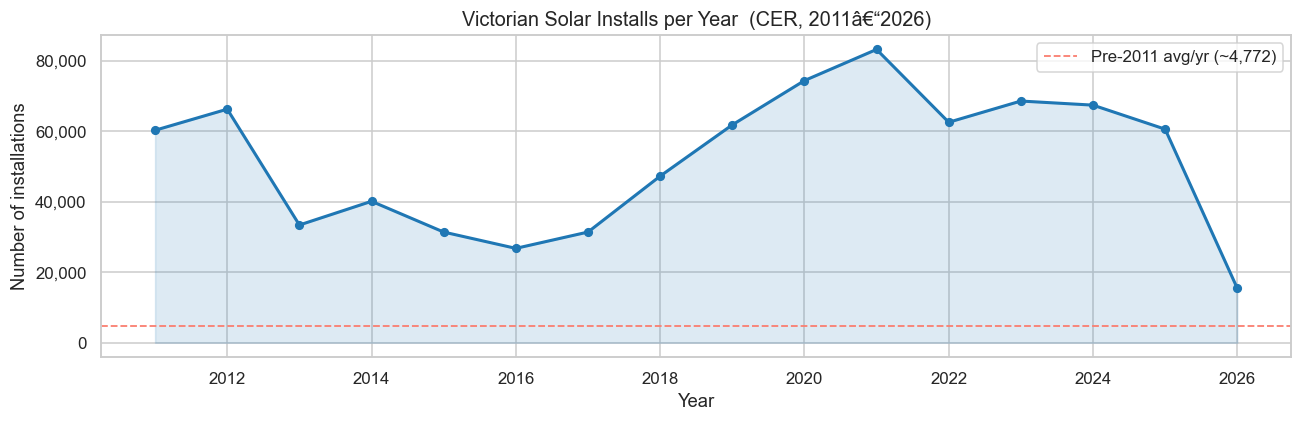

Peak year: 2021  (83,180 installs)


In [26]:
# --- Yearly installs across all Victorian postcodes ---
def col_year(col):
    m = re.search(r'(\d{4})', col)
    return int(m.group(1)) if m else None

by_year = (
    vic[month_cols]
    .sum()               # total per month across all VIC postcodes
    .rename(lambda c: col_year(c))
    .groupby(level=0)
    .sum()
    .reset_index()
)
by_year.columns = ['year', 'installs']

pre2011_total = int(vic['pre2011'].sum())

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(by_year['year'], by_year['installs'],
        color=sns.color_palette()[0], linewidth=2, marker='o', markersize=5)
ax.fill_between(by_year['year'], by_year['installs'],
                alpha=0.15, color=sns.color_palette()[0])
ax.axhline(pre2011_total / 10, color='salmon', linestyle='--', linewidth=1.2,
           label=f'Pre-2011 avg/yr (~{pre2011_total//10:,})')
ax.set_title('Victorian Solar Installs per Year  (CER, 2011â€“2026)', fontsize=13)
ax.set_xlabel('Year')
ax.set_ylabel('Number of installations')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.legend()
plt.tight_layout()
plt.show()
print(f'Peak year: {by_year.loc[by_year.installs.idxmax(), "year"]}  '
      f'({by_year.installs.max():,.0f} installs)')

Victoria installed **878,220** rooftop solar systems between 2001 and 2025 — roughly one in five of all Australian systems. Two surges stand out: 2011–2012, when federal rebates drove 60,000–66,000 installs per year, and 2020–2022, when pandemic-era incentives pushed the rate past 74,000 per year. That compounding growth means hundreds of thousands of systems are now ageing simultaneously, with no coordinated end-of-life system in place.

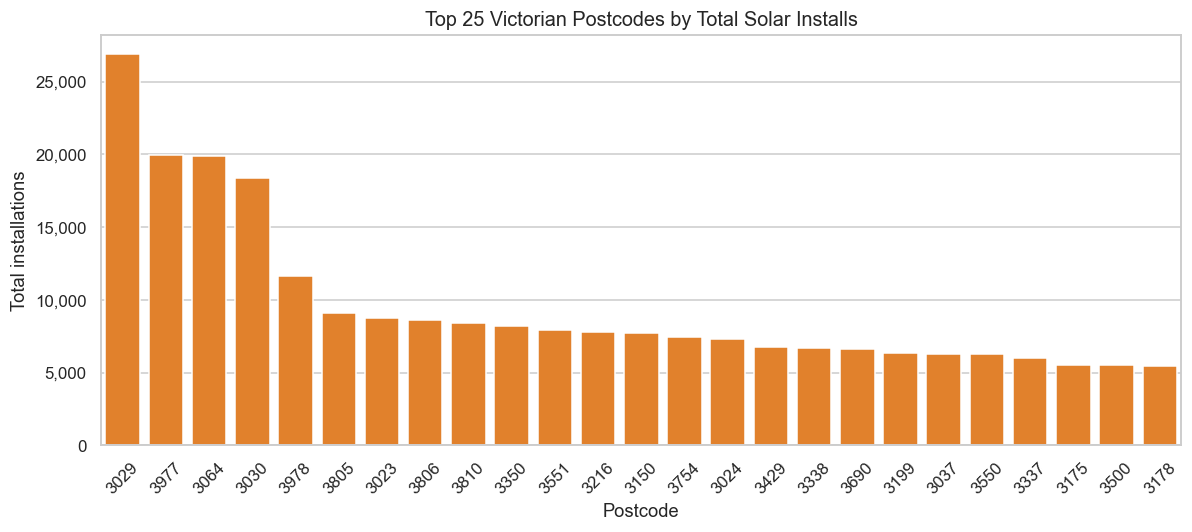

In [27]:
# --- Top 25 Victorian postcodes by all-time total ---
top25 = vic.nlargest(25, 'total')[['postcode', 'total', 'pre2011']].reset_index(drop=True)

fig, ax = plt.subplots(figsize=(11, 5))
sns.barplot(data=top25, x='postcode', y='total', ax=ax, color=sns.color_palette()[1])
ax.set_title('Top 25 Victorian Postcodes by Total Solar Installs', fontsize=13)
ax.set_xlabel('Postcode')
ax.set_ylabel('Total installations')
ax.tick_params(axis='x', rotation=45)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
plt.tight_layout()
plt.show()

Solar adoption is heavily concentrated in outer-western Melbourne's growth corridors. Wyndham (3029) alone has **26,873 systems** — more than any other Victorian postcode. Geographic concentration is an advantage for collection logistics: the end-of-life wave does not arrive everywhere at once. It clusters in predictable suburbs where targeted routes can be planned years in advance.

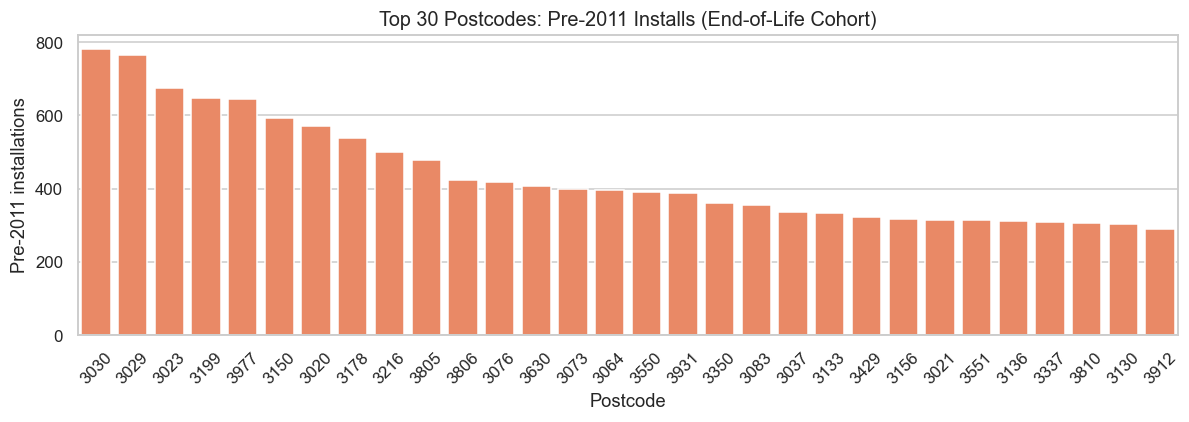

Total pre-2011 VIC installs: 47,721  (these are 15+ years old â€” prime end-of-life collection targets)


In [28]:
# --- End-of-life cohort: pre-2011 installations by postcode (top 30) ---
# Systems installed before 2011 are 15+ years old â€” high end-of-life risk.
eol = vic[vic['pre2011'] > 0].nlargest(30, 'pre2011')[['postcode', 'pre2011']]

fig, ax = plt.subplots(figsize=(11, 4))
sns.barplot(data=eol, x='postcode', y='pre2011', ax=ax, color='coral')
ax.set_title('Top 30 Postcodes: Pre-2011 Installs (End-of-Life Cohort)', fontsize=13)
ax.set_xlabel('Postcode')
ax.set_ylabel('Pre-2011 installations')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()
print(f'Total pre-2011 VIC installs: {pre2011_total:,}  '
      f'(these are 15+ years old â€” prime end-of-life collection targets)')

**47,721** Victorian systems were installed before 2011 and are now 15+ years old — at or past inverter end-of-life (typically 10–12 years) and approaching panel end-of-life (25 years). These are the highest-priority collection targets today. The same outer-suburban postcodes that led the early solar boom now carry the largest near-term end-of-life burden, making them the natural starting point for a proactive collection program.

---
## Victoria Waste Infrastructure ()

Source: Sustainability Victoria. Each row is one real facility: name, owner, type, suburb, LGA, and GPS coordinates.

In [29]:
waste = pd.read_csv(DATA + 'vic_waste_infrastructure.csv')
waste.columns = waste.columns.str.strip()
print(f'Facilities: {len(waste):,}   Columns: {list(waste.columns)}')
waste[['Facility Name','Facility Type','Infrastructure Type','Suburb','LGA']].head(4)

Facilities: 664   Columns: ['Facility Name', 'Facility Owner', 'Facility Type', 'Infrastructure Type', 'Address', 'Suburb', 'LGA', 'Latitude', 'Longitude']


,Facility Name,Facility Type,Infrastructure Type,Suburb,LGA
0,BE Bioenergy,Reprocessor,Thermal energy from waste,Kaniva,West Wimmera
1,Rupanyup Transfer Station,Resource Recovery Centre,Transfer station,Rupanyup,Yarriambiack
2,Minyip Transfer Station,Resource Recovery Centre,Transfer station,Minyip,Yarriambiack
3,Beulah Transfer Station,Resource Recovery Centre,Transfer station,Beulah,Yarriambiack


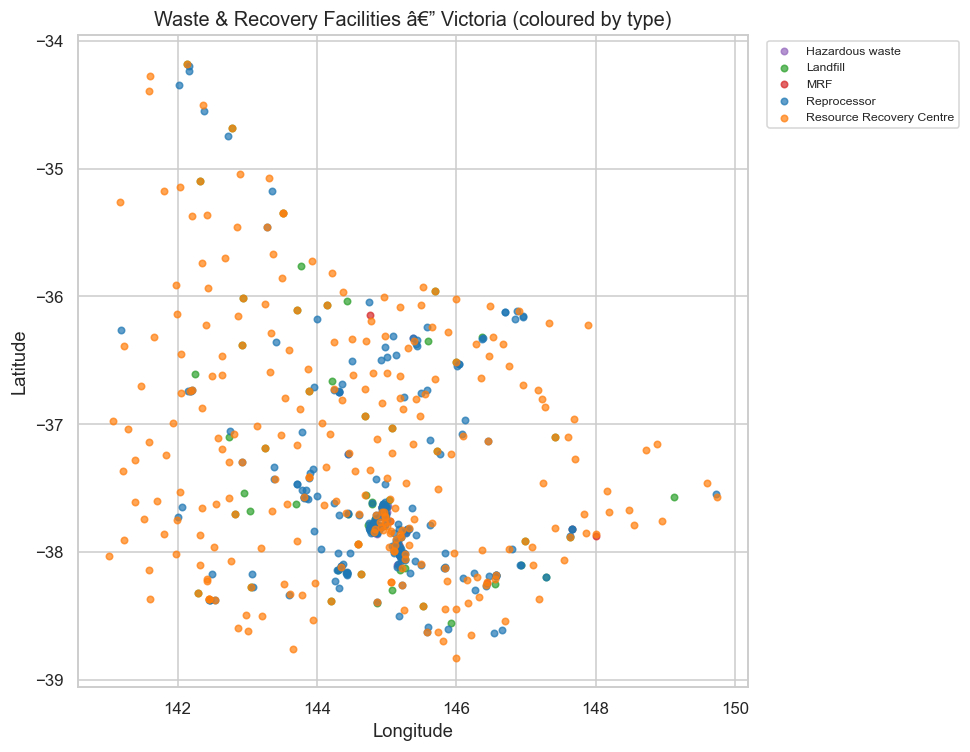

Facilities plotted: 664 / 664


In [30]:
# --- Geographic scatter of facilities coloured by Facility Type ---
geo = waste.dropna(subset=['Latitude', 'Longitude']).copy()
geo['Latitude'] = pd.to_numeric(geo['Latitude'], errors='coerce')
geo['Longitude'] = pd.to_numeric(geo['Longitude'], errors='coerce')
geo = geo.dropna(subset=['Latitude', 'Longitude'])

types = geo['Facility Type'].unique()
palette = dict(zip(types, sns.color_palette('tab10', len(types))))

fig, ax = plt.subplots(figsize=(9, 7))
for ftype_name, group in geo.groupby('Facility Type'):
    ax.scatter(group['Longitude'], group['Latitude'],
               label=ftype_name, s=18, alpha=0.7, color=palette[ftype_name])
ax.set_title('Waste & Recovery Facilities â€” Victoria (coloured by type)', fontsize=13)
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()
print(f'Facilities plotted: {len(geo):,} / {len(waste):,}')

Victoria has **664 mapped waste and resource recovery facilities**, but none are designated solar panel processors. The network is dominated by general-purpose reprocessors (282) and resource recovery centres (269), with only 10 MRFs and no solar-specific capacity on record. Recovery infrastructure exists but is uncoordinated: facilities are spread across the state with no routing system connecting ageing solar clusters to appropriate processors. That gap is the operational problem SolarCycle solves.

---
## Summary

| Dataset | Key insight for SolarCycle |
|---|---|
| CER postcode | 878k Victorian systems, two boom cycles; hundreds of thousands now ageing simultaneously |
| CER pre-2011 cohort | 47,721 systems 15+ years old; clustered in outer-western Melbourne growth suburbs |
| Waste infrastructure | 664 facilities, none solar-specific; no routing system connecting supply to recovery |

**The product gap:** the wave is real, the geography is known, and recovery sites exist — but there is no operational layer connecting them.